# QB Draft season features

## tl;dr

This notebook aggregates the validated QB weekly Silver facts into a Draft Analysis Gold dataset at one row per `player_id + season` for the 2023–2025 regular seasons.

The output contains **245 QB player-seasons and 107 columns** across three season partitions. It preserves every observed season, including two seasons without weekly-stat evidence. The approved eligibility rule identifies 111 seasons with at least eight observed games and 200 complete dropbacks for within-season percentile comparisons; ineligible rows remain in the dataset with null percentiles.

Official production remains separate from canonical PBP opportunity. Complete dropbacks include attempts, sacks, and scrambles, while kneels remain excluded from meaningful QB rushing. The four-point passing-touchdown full-PPR contract, source reconciliation, eligibility, grain, and Parquet round-trip checks all pass.

## Context & Methods

### Scope

- Seasons: 2023–2025
- Season type: regular season only
- Population: contextual QB observations established in `silver_qb_week`
- Input: season-partitioned `silver_qb_week`
- Output: season-partitioned `gold/draft/qb_season_features`
- Output grain: `player_id + season`
- Default scoring: full PPR with four-point passing touchdowns

This is the third decision-oriented Draft Gold prototype. It summarizes passing control, complete dropbacks, meaningful rushing, production, efficiency, and fantasy scoring while keeping the calculation components visible.

### Key assumptions

- Every contextual QB season remains in Gold, even if it is not eligible for percentile comparisons.
- Traded players have one combined season row. `teams_played_for` preserves chronological team order, and `final_team` is the team on the latest observed week.
- Official passing and rushing statistics remain source production. Canonical attempts, sacks, dropbacks, scrambles, designed runs, and kneels remain separate PBP opportunity fields.
- `complete_dropbacks` equals canonical pass attempts plus sacks plus scrambles. `passing_dropbacks` excludes scrambles.
- `meaningful_qb_rush_attempts` equals designed QB runs plus scrambles and excludes kneels.
- Opportunity shares are ratios of season totals over the player’s observed games, not averages of weekly percentages.
- Efficiency rates are null when their denominator is zero. Fantasy points remain null when a season has no weekly-stat production evidence.
- Percentiles are calculated within season only among QB seasons with at least eight observed games and 200 complete dropbacks. Ineligible rows remain present with null percentile fields.

## Data

### 1. Set up paths, grain, and feature groups

The complete output order is declared before transformation so the persisted schema is easy to review and test.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEASONS = [2023, 2024, 2025]
QB_POSITION_LABELS = {"QB"}
GOLD_GRAIN = ["player_id", "season"]

MIN_PERCENTILE_GAMES = 8
MIN_PERCENTILE_DROPBACKS = 200

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

SILVER_QB_WEEK_DIR = PROJECT_ROOT / "data/silver/qb_week"
GOLD_QB_SEASON_DIR = PROJECT_ROOT / "data/gold/draft/qb_season_features"

QB_INPUT_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "season_type",
    "team",
    "display_name",
    "stats_position",
    "snap_position",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "passing_completions",
    "passing_attempts",
    "passing_yards",
    "passing_touchdowns",
    "passing_interceptions",
    "sacks_suffered",
    "passing_first_downs",
    "passing_2pt_conversions",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "pbp_pass_attempts",
    "pbp_sacks",
    "qb_spikes",
    "passing_dropbacks",
    "qb_dropbacks",
    "pbp_rush_attempts",
    "qb_kneels",
    "qb_scrambles",
    "designed_qb_rush_attempts",
    "meaningful_qb_rush_attempts",
    "red_zone_qb_rush_attempts",
    "goal_line_qb_rush_attempts",
    "team_dropbacks",
    "team_pass_attempts",
    "team_sacks",
    "team_rush_attempts",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_qb_kneels",
    "team_qb_spikes",
    "team_qb_scrambles",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

IDENTITY_COLUMNS = [
    "player_id",
    "season",
    "display_name",
    "position",
    "positions_observed",
    "teams_played_for",
    "team_count",
    "final_team",
]

PARTICIPATION_COLUMNS = [
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    "offense_snaps_per_game",
]

PASSING_COLUMNS = [
    "completions",
    "passing_attempts",
    "canonical_pass_attempts",
    "passing_yards",
    "passing_touchdowns",
    "passing_interceptions",
    "sacks_suffered",
    "canonical_sacks",
    "qb_spikes",
    "passing_dropbacks",
    "complete_dropbacks",
    "passing_first_downs",
    "passing_2pt_conversions",
]

RUSHING_COLUMNS = [
    "rushing_attempts",
    "canonical_rush_attempts",
    "qb_kneels",
    "qb_scrambles",
    "designed_qb_rush_attempts",
    "meaningful_qb_rush_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "red_zone_qb_rush_attempts",
    "goal_line_qb_rush_attempts",
]

OTHER_PRODUCTION_COLUMNS = [
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
]

TEAM_DENOMINATOR_COLUMNS = [
    "team_dropbacks",
    "team_pass_attempts",
    "team_sacks",
    "team_rush_attempts",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_qb_kneels",
    "team_qb_spikes",
    "team_qb_scrambles",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

SHARE_COLUMNS = [
    "dropback_share",
    "pass_attempt_share",
    "meaningful_qb_rush_share",
    "designed_qb_rush_share",
    "qb_scramble_share",
    "red_zone_qb_rush_share",
    "goal_line_qb_rush_share",
]

EFFICIENCY_COLUMNS = [
    "completion_percentage",
    "passing_yards_per_attempt",
    "passing_yards_per_passing_dropback",
    "passing_touchdown_rate",
    "interception_rate",
    "sack_rate",
    "passing_first_down_rate",
    "rushing_yards_per_attempt",
    "rushing_first_down_rate",
    "rushing_touchdown_rate",
    "scramble_rate",
    "ppr_fantasy_points_per_complete_dropback",
]

PER_GAME_COLUMNS = [
    "complete_dropbacks_per_game",
    "passing_attempts_per_game",
    "completions_per_game",
    "passing_yards_per_game",
    "passing_touchdowns_per_game",
    "passing_interceptions_per_game",
    "sacks_suffered_per_game",
    "meaningful_qb_rush_attempts_per_game",
    "rushing_yards_per_game",
    "rushing_touchdowns_per_game",
    "ppr_fantasy_points_per_game",
]

FANTASY_POINT_COLUMNS = [
    "passing_fantasy_points",
    "rushing_fantasy_points",
    "receiving_fantasy_points",
    "special_teams_fantasy_points",
    "fumble_lost_points",
    "ppr_fantasy_points",
]

PERCENTILE_DEFINITIONS = {
    "complete_dropbacks_percentile": "complete_dropbacks",
    "dropback_share_percentile": "dropback_share",
    "passing_yards_percentile": "passing_yards",
    "passing_touchdowns_percentile": "passing_touchdowns",
    "completion_percentage_percentile": "completion_percentage",
    "passing_yards_per_attempt_percentile": "passing_yards_per_attempt",
    "passing_yards_per_passing_dropback_percentile": "passing_yards_per_passing_dropback",
    "meaningful_qb_rush_attempts_percentile": "meaningful_qb_rush_attempts",
    "rushing_yards_percentile": "rushing_yards",
    "ppr_fantasy_points_per_game_percentile": "ppr_fantasy_points_per_game",
}

GOLD_COLUMNS = [
    *IDENTITY_COLUMNS,
    *PARTICIPATION_COLUMNS,
    *PASSING_COLUMNS,
    *RUSHING_COLUMNS,
    *OTHER_PRODUCTION_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_COLUMNS,
    *EFFICIENCY_COLUMNS,
    *PER_GAME_COLUMNS,
    *FANTASY_POINT_COLUMNS,
    "percentile_eligible",
    *PERCENTILE_DEFINITIONS.keys(),
]

assert len(QB_INPUT_COLUMNS) == 59
assert len(GOLD_COLUMNS) == 107
assert len(GOLD_COLUMNS) == len(set(GOLD_COLUMNS))

pd.set_option("display.max_columns", 115)

### 2. Define the calculation contracts

The contracts state the numerator and denominator choices before any features are calculated. Season shares and rates use summed components rather than averaging weekly percentages.

In [2]:
share_contract = pd.DataFrame(
    [
        ["dropback_share", "complete_dropbacks", "team_dropbacks"],
        ["pass_attempt_share", "canonical_pass_attempts", "team_pass_attempts"],
        ["meaningful_qb_rush_share", "meaningful_qb_rush_attempts", "team_non_kneel_rush_attempts"],
        ["designed_qb_rush_share", "designed_qb_rush_attempts", "team_designed_rush_attempts"],
        ["qb_scramble_share", "qb_scrambles", "team_qb_scrambles"],
        ["red_zone_qb_rush_share", "red_zone_qb_rush_attempts", "team_red_zone_rush_attempts"],
        ["goal_line_qb_rush_share", "goal_line_qb_rush_attempts", "team_goal_line_rush_attempts"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

efficiency_contract = pd.DataFrame(
    [
        ["completion_percentage", "completions", "passing_attempts"],
        ["passing_yards_per_attempt", "passing_yards", "passing_attempts"],
        ["passing_yards_per_passing_dropback", "passing_yards", "passing_dropbacks"],
        ["passing_touchdown_rate", "passing_touchdowns", "passing_attempts"],
        ["interception_rate", "passing_interceptions", "passing_attempts"],
        ["sack_rate", "canonical_sacks", "passing_dropbacks"],
        ["passing_first_down_rate", "passing_first_downs", "passing_attempts"],
        ["rushing_yards_per_attempt", "rushing_yards", "rushing_attempts"],
        ["rushing_first_down_rate", "rushing_first_downs", "rushing_attempts"],
        ["rushing_touchdown_rate", "rushing_touchdowns", "rushing_attempts"],
        ["scramble_rate", "qb_scrambles", "complete_dropbacks"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

display(share_contract)
efficiency_contract

,feature,season_numerator,season_denominator
0,dropback_share,complete_dropbacks,team_dropbacks
1,pass_attempt_share,canonical_pass_attempts,team_pass_attempts
2,meaningful_qb_rush_share,meaningful_qb_rush_attempts,team_non_kneel_rush_attempts
3,designed_qb_rush_share,designed_qb_rush_attempts,team_designed_rush_attempts
4,qb_scramble_share,qb_scrambles,team_qb_scrambles
5,red_zone_qb_rush_share,red_zone_qb_rush_attempts,team_red_zone_rush_attempts
6,goal_line_qb_rush_share,goal_line_qb_rush_attempts,team_goal_line_rush_attempts


,feature,season_numerator,season_denominator
0,completion_percentage,completions,passing_attempts
1,passing_yards_per_attempt,passing_yards,passing_attempts
2,passing_yards_per_passing_dropback,passing_yards,passing_dropbacks
3,passing_touchdown_rate,passing_touchdowns,passing_attempts
4,interception_rate,passing_interceptions,passing_attempts
5,sack_rate,canonical_sacks,passing_dropbacks
6,passing_first_down_rate,passing_first_downs,passing_attempts
7,rushing_yards_per_attempt,rushing_yards,rushing_attempts
8,rushing_first_down_rate,rushing_first_downs,rushing_attempts
9,rushing_touchdown_rate,rushing_touchdowns,rushing_attempts


In [3]:
scoring_contract = pd.DataFrame(
    [
        ["passing yard", 0.04],
        ["passing touchdown", 4.0],
        ["interception", -2.0],
        ["passing two-point conversion", 2.0],
        ["reception", 1.0],
        ["receiving yard", 0.1],
        ["receiving touchdown", 6.0],
        ["rushing yard", 0.1],
        ["rushing touchdown", 6.0],
        ["rushing or receiving two-point conversion", 2.0],
        ["fumble lost", -2.0],
        ["special-teams touchdown", 6.0],
        ["sack", 0.0],
    ],
    columns=["event", "full_ppr_points"],
)

scoring_contract

,event,full_ppr_points
0,passing yard,0.04
1,passing touchdown,4.00
2,interception,-2.00
3,passing two-point conversion,2.00
4,reception,1.00
5,receiving yard,0.10
6,receiving touchdown,6.00
7,rushing yard,0.10
8,rushing touchdown,6.00
9,rushing or receiving two-point conversion,2.00


### 3. Load the QB Silver partitions

In [4]:
qb_week_paths = sorted(SILVER_QB_WEEK_DIR.glob("*.parquet"))

assert len(qb_week_paths) == len(SEASONS)

qb_week = pd.concat(
    [pd.read_parquet(path, columns=QB_INPUT_COLUMNS) for path in qb_week_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [["silver_qb_week", len(qb_week), 71, len(qb_week.columns), len(qb_week_paths)]],
    columns=["input", "rows", "columns_available", "columns_selected", "files"],
)

assert set(qb_week["season"].unique()) == set(SEASONS)
input_summary

,input,rows,columns_available,columns_selected,files
0,silver_qb_week,2163,71,59,3


## Results

### 4. Validate the input grain and select regular-season observations

Postseason rows remain in Silver but do not enter the Draft season profile. The Gold population is therefore defined explicitly before aggregation.

In [5]:
SILVER_QB_GRAIN = ["player_id", "season", "week", "team"]

assert qb_week[SILVER_QB_GRAIN].notna().all().all()
assert not qb_week.duplicated(SILVER_QB_GRAIN).any()

qb_regular = (
    qb_week.loc[qb_week["season_type"].eq("REG")]
    .sort_values(["player_id", "season", "week", "team"])
    .reset_index(drop=True)
)

assert qb_regular["game_id"].notna().all()
assert not qb_regular.duplicated(SILVER_QB_GRAIN).any()
assert not qb_regular.duplicated(["player_id", "season", "game_id"]).any()

regular_population_summary = (
    qb_regular.groupby("season", dropna=False)
    .agg(
        player_weeks=("game_id", "size"),
        player_seasons=("player_id", "nunique"),
        teams=("team", "nunique"),
    )
    .reset_index()
)

regular_population_summary

,season,player_weeks,player_seasons,teams
0,2023,700,84,32
1,2024,684,79,32
2,2025,687,82,32


### 5. Build season identity, position, and team context

Valid weekly stat-position evidence is preferred; snap position supplies the contextual label when the stat row is absent. Players who change teams still retain one player-season row with their chronological team path visible.

In [6]:
qb_regular["contextual_position"] = qb_regular["stats_position"].where(
    qb_regular["stats_position"].isin(QB_POSITION_LABELS),
    qb_regular["snap_position"].where(
        qb_regular["snap_position"].isin(QB_POSITION_LABELS)
    ),
)

assert qb_regular["contextual_position"].notna().all()


def ordered_unique_text(values):
    return ", ".join(dict.fromkeys(value for value in values if pd.notna(value)))


identity_validation = (
    qb_regular.groupby(GOLD_GRAIN, dropna=False)
    .agg(display_names=("display_name", "nunique"))
    .reset_index()
)
assert identity_validation["display_names"].le(1).all()

season_context = (
    qb_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        display_name=("display_name", "last"),
        position=("contextual_position", "last"),
        positions_observed=("contextual_position", ordered_unique_text),
        teams_played_for=("team", ordered_unique_text),
        team_count=("team", "nunique"),
        final_team=("team", "last"),
    )
    .reset_index()
)

assert not season_context.duplicated(GOLD_GRAIN).any()
assert season_context["display_name"].notna().all()
assert season_context["position"].isin(QB_POSITION_LABELS).all()
assert season_context.apply(
    lambda row: len(row["teams_played_for"].split(", ")) == row["team_count"],
    axis=1,
).all()
assert season_context.apply(
    lambda row: row["final_team"] in row["teams_played_for"].split(", "),
    axis=1,
).all()

season_context.head()

,player_id,season,display_name,position,positions_observed,teams_played_for,team_count,final_team
0,00-0022942,2025,Philip Rivers,QB,QB,IND,1,IND
1,00-0023459,2023,Aaron Rodgers,QB,QB,NYJ,1,NYJ
2,00-0023459,2024,Aaron Rodgers,QB,QB,NYJ,1,NYJ
3,00-0023459,2025,Aaron Rodgers,QB,QB,PIT,1,PIT
4,00-0026158,2023,Joe Flacco,QB,QB,CLE,1,CLE


### 6. Aggregate participation, production, and opportunity

The aggregation keeps nullable source production separate from complete PBP opportunity. Source statistics stay null when an entire season lacks stat evidence, while canonical PBP counts remain observed zeroes.

In [7]:
def sum_with_minimum_evidence(values):
    return values.sum(min_count=1)


def count_confirmed_true(values):
    return values.fillna(False).sum()


season_totals = (
    qb_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        games_observed=("game_id", "nunique"),
        games_with_stat_record=("has_stat_record", "sum"),
        games_with_snap_record=("has_snap_record", "sum"),
        games_participated=("participated_game", count_confirmed_true),
        games_offensive_participant=("offensive_participant", count_confirmed_true),
        offense_snaps=("offense_snaps", sum_with_minimum_evidence),
        completions=("passing_completions", sum_with_minimum_evidence),
        passing_attempts=("passing_attempts", sum_with_minimum_evidence),
        canonical_pass_attempts=("pbp_pass_attempts", "sum"),
        passing_yards=("passing_yards", sum_with_minimum_evidence),
        passing_touchdowns=("passing_touchdowns", sum_with_minimum_evidence),
        passing_interceptions=("passing_interceptions", sum_with_minimum_evidence),
        sacks_suffered=("sacks_suffered", sum_with_minimum_evidence),
        canonical_sacks=("pbp_sacks", "sum"),
        qb_spikes=("qb_spikes", "sum"),
        passing_dropbacks=("passing_dropbacks", "sum"),
        complete_dropbacks=("qb_dropbacks", "sum"),
        passing_first_downs=("passing_first_downs", sum_with_minimum_evidence),
        passing_2pt_conversions=("passing_2pt_conversions", sum_with_minimum_evidence),
        rushing_attempts=("rushing_attempts", sum_with_minimum_evidence),
        canonical_rush_attempts=("pbp_rush_attempts", "sum"),
        qb_kneels=("qb_kneels", "sum"),
        qb_scrambles=("qb_scrambles", "sum"),
        designed_qb_rush_attempts=("designed_qb_rush_attempts", "sum"),
        meaningful_qb_rush_attempts=("meaningful_qb_rush_attempts", "sum"),
        rushing_yards=("rushing_yards", sum_with_minimum_evidence),
        rushing_touchdowns=("rushing_touchdowns", sum_with_minimum_evidence),
        rushing_first_downs=("rushing_first_downs", sum_with_minimum_evidence),
        rushing_2pt_conversions=("rushing_2pt_conversions", sum_with_minimum_evidence),
        red_zone_qb_rush_attempts=("red_zone_qb_rush_attempts", "sum"),
        goal_line_qb_rush_attempts=("goal_line_qb_rush_attempts", "sum"),
        receiving_targets=("receiving_targets", sum_with_minimum_evidence),
        receptions=("receptions", sum_with_minimum_evidence),
        receiving_yards=("receiving_yards", sum_with_minimum_evidence),
        receiving_touchdowns=("receiving_touchdowns", sum_with_minimum_evidence),
        receiving_first_downs=("receiving_first_downs", sum_with_minimum_evidence),
        receiving_2pt_conversions=("receiving_2pt_conversions", sum_with_minimum_evidence),
        fumbles=("fumbles", sum_with_minimum_evidence),
        fumbles_lost=("fumbles_lost", sum_with_minimum_evidence),
        special_teams_touchdowns=("special_teams_touchdowns", sum_with_minimum_evidence),
        team_dropbacks=("team_dropbacks", "sum"),
        team_pass_attempts=("team_pass_attempts", "sum"),
        team_sacks=("team_sacks", "sum"),
        team_rush_attempts=("team_rush_attempts", "sum"),
        team_non_kneel_rush_attempts=("team_non_kneel_rush_attempts", "sum"),
        team_designed_rush_attempts=("team_designed_rush_attempts", "sum"),
        team_qb_kneels=("team_qb_kneels", "sum"),
        team_qb_spikes=("team_qb_spikes", "sum"),
        team_qb_scrambles=("team_qb_scrambles", "sum"),
        team_red_zone_rush_attempts=("team_red_zone_rush_attempts", "sum"),
        team_goal_line_rush_attempts=("team_goal_line_rush_attempts", "sum"),
    )
    .reset_index()
)

qb_season_features = season_context.merge(
    season_totals,
    on=GOLD_GRAIN,
    how="inner",
    validate="one_to_one",
)

assert len(qb_season_features) == qb_regular.groupby(GOLD_GRAIN).ngroups
assert not qb_season_features.duplicated(GOLD_GRAIN).any()

qb_season_features[[
    "season",
    "display_name",
    "games_observed",
    "passing_attempts",
    "complete_dropbacks",
    "meaningful_qb_rush_attempts",
]].head()

,season,display_name,games_observed,passing_attempts,complete_dropbacks,meaningful_qb_rush_attempts
0,2025,Philip Rivers,3,92,97,1
1,2023,Aaron Rodgers,1,1,2,0
2,2024,Aaron Rodgers,17,584,640,17
3,2025,Aaron Rodgers,16,498,538,13
4,2023,Joe Flacco,5,204,212,5


### 7. Validate QB workload identities and reconcile to Silver

Gold changes the grain, not the underlying totals. Complete dropbacks and meaningful rushing must retain the Silver identities, and aggregated production and opportunity must sum back to the selected regular-season population.

In [8]:
assert qb_season_features["passing_dropbacks"].eq(
    qb_season_features["canonical_pass_attempts"]
    + qb_season_features["canonical_sacks"]
).all()
assert qb_season_features["complete_dropbacks"].eq(
    qb_season_features["passing_dropbacks"]
    + qb_season_features["qb_scrambles"]
).all()
assert qb_season_features["meaningful_qb_rush_attempts"].eq(
    qb_season_features["designed_qb_rush_attempts"]
    + qb_season_features["qb_scrambles"]
).all()

RECONCILIATION_COLUMNS = {
    "completions": "passing_completions",
    "passing_attempts": "passing_attempts",
    "canonical_pass_attempts": "pbp_pass_attempts",
    "passing_yards": "passing_yards",
    "passing_touchdowns": "passing_touchdowns",
    "passing_interceptions": "passing_interceptions",
    "sacks_suffered": "sacks_suffered",
    "canonical_sacks": "pbp_sacks",
    "passing_dropbacks": "passing_dropbacks",
    "complete_dropbacks": "qb_dropbacks",
    "rushing_attempts": "rushing_attempts",
    "canonical_rush_attempts": "pbp_rush_attempts",
    "qb_kneels": "qb_kneels",
    "qb_scrambles": "qb_scrambles",
    "designed_qb_rush_attempts": "designed_qb_rush_attempts",
    "meaningful_qb_rush_attempts": "meaningful_qb_rush_attempts",
    "rushing_yards": "rushing_yards",
    "rushing_touchdowns": "rushing_touchdowns",
}

reconciliation_records = []
for gold_column, silver_column in RECONCILIATION_COLUMNS.items():
    silver_total = qb_regular[silver_column].sum()
    gold_total = qb_season_features[gold_column].sum()
    reconciliation_records.append(
        [gold_column, silver_total, gold_total, gold_total - silver_total]
    )

season_total_reconciliation = pd.DataFrame(
    reconciliation_records,
    columns=["metric", "Silver_regular_total", "Gold_season_total", "difference"],
)

assert np.isclose(
    season_total_reconciliation["difference"].astype("float64"),
    0,
    rtol=0,
    atol=1e-12,
).all()

source_opportunity_reconciliation = pd.DataFrame(
    [
        [
            "official pass attempts vs canonical PBP pass attempts",
            qb_season_features["passing_attempts"].sum(),
            qb_season_features["canonical_pass_attempts"].sum(),
        ],
        [
            "official sacks vs canonical PBP sacks",
            qb_season_features["sacks_suffered"].sum(),
            qb_season_features["canonical_sacks"].sum(),
        ],
        [
            "official rush attempts vs canonical PBP rush attempts",
            qb_season_features["rushing_attempts"].sum(),
            qb_season_features["canonical_rush_attempts"].sum(),
        ],
    ],
    columns=["comparison", "source_total", "canonical_total"],
)
source_opportunity_reconciliation["difference"] = (
    source_opportunity_reconciliation["canonical_total"]
    - source_opportunity_reconciliation["source_total"]
)

assert source_opportunity_reconciliation["difference"].tolist() == [-1, 0, 0]

display(season_total_reconciliation)
source_opportunity_reconciliation

,metric,Silver_regular_total,Gold_season_total,difference
0,completions,34609,34609,0
1,passing_attempts,53478,53478,0
2,canonical_pass_attempts,53477,53477,0
3,passing_yards,377377,377377,0
4,passing_touchdowns,2359,2359,0
5,passing_interceptions,1192,1192,0
6,sacks_suffered,3992,3992,0
7,canonical_sacks,3992,3992,0
8,passing_dropbacks,57469,57469,0
9,complete_dropbacks,60648,60648,0


,comparison,source_total,canonical_total,difference
0,official pass attempts vs canonical PBP pass a...,53478,53477,-1
1,official sacks vs canonical PBP sacks,3992,3992,0
2,official rush attempts vs canonical PBP rush a...,6985,6985,0


### 8. Calculate season opportunity shares

Each share divides summed player opportunity by the corresponding summed team denominator over the player’s observed games. A zero denominator produces null; observed zero player opportunity with a valid denominator produces zero.

In [9]:
SHARE_DEFINITIONS = {
    row.feature: (row.season_numerator, row.season_denominator)
    for row in share_contract.itertuples(index=False)
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = qb_season_features[denominator_column].ne(0)
    qb_season_features[share_column] = (
        qb_season_features[numerator_column]
        .div(qb_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert qb_season_features.loc[~valid_denominator, share_column].isna().all()
    assert qb_season_features[share_column].dropna().between(0, 1, inclusive="both").all()

share_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": qb_season_features[share_column].notna().sum(),
            "minimum": qb_season_features[share_column].min(),
            "maximum": qb_season_features[share_column].max(),
        }
        for share_column in SHARE_COLUMNS
    ]
)

share_summary

,share,non_null_rows,minimum,maximum
0,dropback_share,245,0.0,1.000000
1,pass_attempt_share,245,0.0,1.000000
2,meaningful_qb_rush_share,245,0.0,0.296203
3,designed_qb_rush_share,245,0.0,0.220000
4,qb_scramble_share,238,0.0,1.000000
5,red_zone_qb_rush_share,243,0.0,0.600000
6,goal_line_qb_rush_share,231,0.0,1.000000


### 9. Calculate efficiency and per-game features

Ratios are calculated from season totals. Official attempts support source-stat efficiencies; canonical PBP dropbacks support sack, scramble, and complete-workload rates. Zero denominators remain null.

In [10]:
RATIO_DEFINITIONS = {
    **{
        row.feature: (row.season_numerator, row.season_denominator)
        for row in efficiency_contract.itertuples(index=False)
    },
    "offense_snaps_per_game": ("offense_snaps", "games_observed"),
    "complete_dropbacks_per_game": ("complete_dropbacks", "games_observed"),
    "passing_attempts_per_game": ("passing_attempts", "games_observed"),
    "completions_per_game": ("completions", "games_observed"),
    "passing_yards_per_game": ("passing_yards", "games_observed"),
    "passing_touchdowns_per_game": ("passing_touchdowns", "games_observed"),
    "passing_interceptions_per_game": ("passing_interceptions", "games_observed"),
    "sacks_suffered_per_game": ("sacks_suffered", "games_observed"),
    "meaningful_qb_rush_attempts_per_game": ("meaningful_qb_rush_attempts", "games_observed"),
    "rushing_yards_per_game": ("rushing_yards", "games_observed"),
    "rushing_touchdowns_per_game": ("rushing_touchdowns", "games_observed"),
}

for feature, (numerator_column, denominator_column) in RATIO_DEFINITIONS.items():
    valid_denominator = qb_season_features[denominator_column].ne(0)
    qb_season_features[feature] = (
        qb_season_features[numerator_column]
        .div(qb_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )

assert qb_season_features["games_observed"].gt(0).all()
qb_season_features[[
    "season",
    "display_name",
    "completion_percentage",
    "passing_yards_per_attempt",
    "scramble_rate",
]].head()

,season,display_name,completion_percentage,passing_yards_per_attempt,scramble_rate
0,2025,Philip Rivers,0.630435,5.913043,0.0
1,2023,Aaron Rodgers,0.0,0.0,0.0
2,2024,Aaron Rodgers,0.630137,6.672945,0.025
3,2025,Aaron Rodgers,0.656627,6.670683,0.022305
4,2023,Joe Flacco,0.602941,7.921569,0.0


### 10. Calculate full-PPR fantasy scoring

The component columns keep the scoring model auditable and reusable. Passing touchdowns are worth four points, sacks have no fantasy penalty, and no yardage or touchdown bonuses are applied.

In [11]:
qb_season_features["passing_fantasy_points"] = (
    0.04 * qb_season_features["passing_yards"]
    + 4 * qb_season_features["passing_touchdowns"]
    - 2 * qb_season_features["passing_interceptions"]
    + 2 * qb_season_features["passing_2pt_conversions"]
).astype("Float64")

qb_season_features["rushing_fantasy_points"] = (
    0.1 * qb_season_features["rushing_yards"]
    + 6 * qb_season_features["rushing_touchdowns"]
    + 2 * qb_season_features["rushing_2pt_conversions"]
).astype("Float64")

qb_season_features["receiving_fantasy_points"] = (
    qb_season_features["receptions"]
    + 0.1 * qb_season_features["receiving_yards"]
    + 6 * qb_season_features["receiving_touchdowns"]
    + 2 * qb_season_features["receiving_2pt_conversions"]
).astype("Float64")

qb_season_features["special_teams_fantasy_points"] = (
    6 * qb_season_features["special_teams_touchdowns"]
).astype("Float64")

qb_season_features["fumble_lost_points"] = (
    -2 * qb_season_features["fumbles_lost"]
).astype("Float64")

qb_season_features["ppr_fantasy_points"] = qb_season_features[
    [
        "passing_fantasy_points",
        "rushing_fantasy_points",
        "receiving_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=5).astype("Float64")

qb_season_features["ppr_fantasy_points_per_game"] = (
    qb_season_features["ppr_fantasy_points"]
    .div(qb_season_features["games_observed"])
    .astype("Float64")
)
qb_season_features["ppr_fantasy_points_per_complete_dropback"] = (
    qb_season_features["ppr_fantasy_points"]
    .div(
        qb_season_features["complete_dropbacks"].where(
            qb_season_features["complete_dropbacks"].ne(0)
        )
    )
    .astype("Float64")
)

scoring_check = qb_season_features[
    [
        "passing_fantasy_points",
        "rushing_fantasy_points",
        "receiving_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=5)

assert np.isclose(
    qb_season_features["ppr_fantasy_points"].dropna().astype("float64"),
    scoring_check.dropna().astype("float64"),
    rtol=0,
    atol=1e-12,
).all()

### 11. Apply percentile eligibility and within-season ranks

Eligibility controls only the comparison population. It never removes a player-season from the dataset. Percentiles run from values near zero to one, with higher values representing more of the named metric.

In [12]:
qb_season_features["percentile_eligible"] = (
    qb_season_features["games_observed"].ge(MIN_PERCENTILE_GAMES)
    & qb_season_features["complete_dropbacks"].ge(MIN_PERCENTILE_DROPBACKS)
)

for percentile_column, metric_column in PERCENTILE_DEFINITIONS.items():
    qb_season_features[percentile_column] = pd.Series(
        pd.NA,
        index=qb_season_features.index,
        dtype="Float64",
    )
    eligible_metric = (
        qb_season_features["percentile_eligible"]
        & qb_season_features[metric_column].notna()
    )
    qb_season_features.loc[eligible_metric, percentile_column] = (
        qb_season_features.loc[eligible_metric]
        .groupby("season")[metric_column]
        .rank(method="average", pct=True)
        .astype("Float64")
    )

assert not qb_season_features.loc[
    ~qb_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().any().any()
assert qb_season_features.loc[
    qb_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().all().all()

eligibility_summary = (
    qb_season_features.groupby("season", dropna=False)
    .agg(
        player_seasons=("player_id", "size"),
        percentile_eligible=("percentile_eligible", "sum"),
    )
    .reset_index()
)
eligibility_summary["ineligible_retained"] = (
    eligibility_summary["player_seasons"]
    - eligibility_summary["percentile_eligible"]
)

eligibility_summary

,season,player_seasons,percentile_eligible,ineligible_retained
0,2023,84,36,48
1,2024,79,38,41
2,2025,82,37,45


### 12. Create `gold_qb_season_features`

The final selection enforces the approved 107-column schema and a stable reader-facing column order.

In [13]:
gold_qb_season_features = (
    qb_season_features[GOLD_COLUMNS]
    .sort_values(["season", "display_name", "player_id"])
    .reset_index(drop=True)
)

INTEGER_COLUMNS = [
    "team_count",
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    *PASSING_COLUMNS,
    *RUSHING_COLUMNS,
    *OTHER_PRODUCTION_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
]

assert len(INTEGER_COLUMNS) == 52
for column in INTEGER_COLUMNS:
    gold_qb_season_features[column] = gold_qb_season_features[column].astype("Int64")

gold_qb_season_features["season"] = gold_qb_season_features["season"].astype("int32")
gold_qb_season_features["percentile_eligible"] = gold_qb_season_features[
    "percentile_eligible"
].astype("boolean")

assert gold_qb_season_features.columns.tolist() == GOLD_COLUMNS
assert len(gold_qb_season_features.columns) == 107
assert gold_qb_season_features[GOLD_GRAIN].notna().all().all()
assert not gold_qb_season_features.duplicated(GOLD_GRAIN).any()

pd.DataFrame(
    {
        "dataset": ["gold_qb_season_features"],
        "rows": [len(gold_qb_season_features)],
        "columns": [len(gold_qb_season_features.columns)],
        "grain": [" + ".join(GOLD_GRAIN)],
        "duplicate_grain_rows": [gold_qb_season_features.duplicated(GOLD_GRAIN).sum()],
        "null_grain_rows": [gold_qb_season_features[GOLD_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,gold_qb_season_features,245,107,player_id + season,0,0


### 13. Validate null behavior and percentile bounds

Seasons without stat evidence retain null official production and fantasy scoring. Complete PBP coverage still preserves confirmed zero opportunity instead of inventing statistical values.

In [14]:
no_stat_seasons = gold_qb_season_features["games_with_stat_record"].eq(0)

assert gold_qb_season_features.loc[no_stat_seasons, "passing_attempts"].isna().all()
assert gold_qb_season_features.loc[no_stat_seasons, "rushing_attempts"].isna().all()
assert gold_qb_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().all()
assert gold_qb_season_features.loc[no_stat_seasons, "complete_dropbacks"].eq(0).all()

for column in PERCENTILE_DEFINITIONS:
    assert gold_qb_season_features[column].dropna().between(0, 1, inclusive="both").all()

null_behavior_summary = pd.DataFrame(
    [
        [
            "player-seasons without weekly-stat evidence",
            no_stat_seasons.sum(),
            gold_qb_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().sum(),
            gold_qb_season_features.loc[no_stat_seasons, "complete_dropbacks"].eq(0).sum(),
        ]
    ],
    columns=["population", "rows", "null_fantasy_points", "zero_complete_dropbacks"],
)

null_behavior_summary

,population,rows,null_fantasy_points,zero_complete_dropbacks
0,player-seasons without weekly-stat evidence,2,2,2


### 14. Check team changes

Team changes across weeks are valid. The single Gold row keeps the chronological team path, count, and final observed team.

In [15]:
traded_player_seasons = (
    gold_qb_season_features.loc[gold_qb_season_features["team_count"].gt(1)]
    [
        [
            "season",
            "display_name",
            "teams_played_for",
            "team_count",
            "final_team",
            "games_observed",
            "complete_dropbacks",
        ]
    ]
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

print(f"Combined QB player-seasons with multiple teams: {len(traded_player_seasons):,}")
traded_player_seasons

Combined QB player-seasons with multiple teams: 4


,season,display_name,teams_played_for,team_count,final_team,games_observed,complete_dropbacks
0,2023,Joshua Dobbs,"ARI, MIN",2,MIN,13,481
1,2023,Malik Cunningham,"NE, BAL",2,BAL,2,1
2,2024,Tim Boyle,"MIA, NYG",2,NYG,3,54
3,2025,Joe Flacco,"CLE, CIN",2,CIN,13,438


### 15. Review recognizable QB seasons

The table provides a direct reasonableness check for passing, rushing, and scoring. It is descriptive rather than a hard-coded external benchmark.

In [16]:
season_leaders = (
    gold_qb_season_features.loc[gold_qb_season_features["ppr_fantasy_points"].notna()]
    .sort_values(["season", "ppr_fantasy_points"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    [
        [
            "season",
            "display_name",
            "games_observed",
            "complete_dropbacks",
            "passing_yards",
            "passing_touchdowns",
            "passing_interceptions",
            "rushing_yards",
            "rushing_touchdowns",
            "ppr_fantasy_points",
            "ppr_fantasy_points_per_game",
        ]
    ]
    .reset_index(drop=True)
)

season_leaders

,season,display_name,games_observed,complete_dropbacks,passing_yards,passing_touchdowns,passing_interceptions,rushing_yards,rushing_touchdowns,ppr_fantasy_points,ppr_fantasy_points_per_game
0,2023,Josh Allen,17,651,4306,29,18,524,15,392.64,23.096471
1,2023,Jalen Hurts,17,622,3858,23,15,605,15,356.82,20.989412
2,2023,Dak Prescott,17,656,4516,36,9,242,2,342.84,20.167059
3,2023,Lamar Jackson,16,560,3678,24,7,821,5,331.22,20.70125
4,2023,Jordan Love,17,633,4159,32,11,247,4,319.06,18.768235
5,2024,Lamar Jackson,17,543,4172,41,4,915,4,430.38,25.316471
6,2024,Josh Allen,17,540,3731,28,6,531,12,379.04,22.296471
7,2024,Joe Burrow,17,722,4918,43,9,201,2,372.82,21.930588
8,2024,Baker Mayfield,17,652,4500,41,16,378,3,365.8,21.517647
9,2024,Jayden Daniels,17,599,3568,25,9,891,6,355.82,20.930588


### 16. Inspect passing control and rushing contribution with scoring

The eligible comparison population appears in both panels. Dropback share shows control of the passing role; meaningful rushing volume shows the designed-run and scramble contribution without counting kneels.

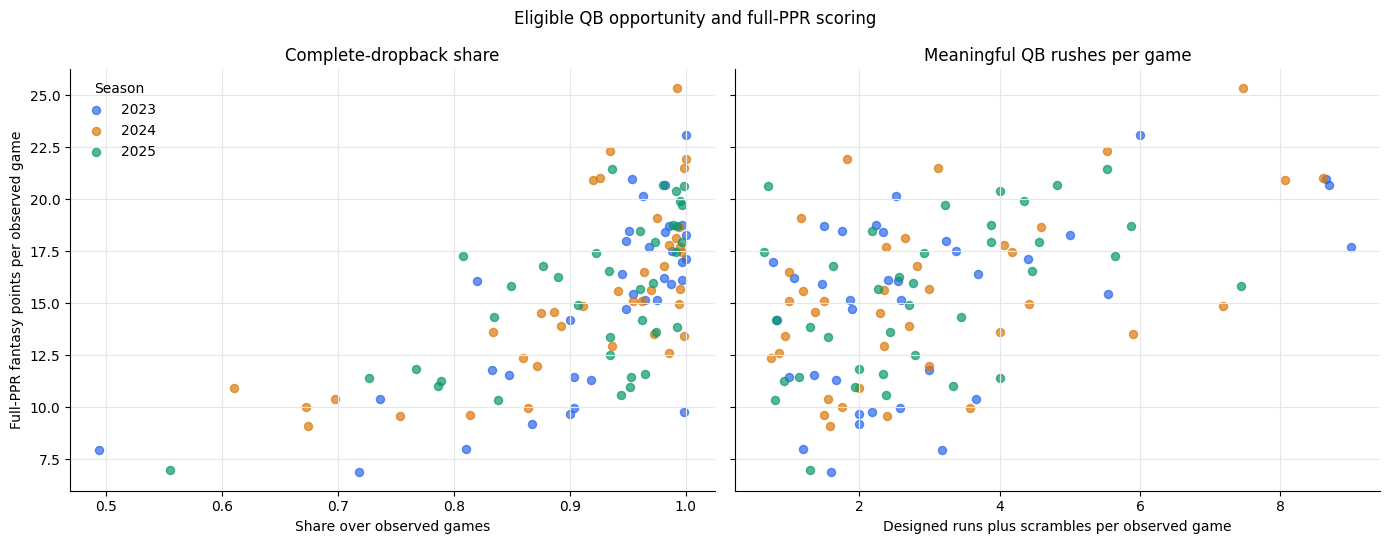

In [17]:
plot_population = gold_qb_season_features.loc[
    gold_qb_season_features["percentile_eligible"]
].copy()

season_colors = {
    2023: "#2563eb",
    2024: "#d97706",
    2025: "#059669",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
plot_definitions = [
    ("dropback_share", "Complete-dropback share", "Share over observed games"),
    (
        "meaningful_qb_rush_attempts_per_game",
        "Meaningful QB rushes per game",
        "Designed runs plus scrambles per observed game",
    ),
]

for axis, (x_column, title, x_label) in zip(axes, plot_definitions):
    for season in SEASONS:
        season_rows = plot_population.loc[plot_population["season"].eq(season)]
        axis.scatter(
            season_rows[x_column].astype("float64"),
            season_rows["ppr_fantasy_points_per_game"].astype("float64"),
            label=str(season),
            color=season_colors[season],
            alpha=0.68,
            s=34,
        )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.grid(color="#e5e7eb", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Full-PPR fantasy points per observed game")
axes[0].legend(title="Season", frameon=False)
fig.suptitle("Eligible QB opportunity and full-PPR scoring")
fig.tight_layout()
plt.show()

### 17. Persist season-partitioned Gold Parquet

Each partition is written and immediately reloaded. Shape, column order, dtypes, season membership, and the declared player-season grain must survive the round trip.

In [18]:
GOLD_QB_SEASON_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    season_partition = (
        gold_qb_season_features.loc[gold_qb_season_features["season"].eq(season)]
        .sort_values(["display_name", "player_id"])
        .reset_index(drop=True)
    )
    output_path = GOLD_QB_SEASON_DIR / f"qb_season_features_{season}.parquet"
    season_partition.to_parquet(output_path, index=False)
    reloaded = pd.read_parquet(output_path)

    assert reloaded.shape == season_partition.shape
    assert reloaded.columns.tolist() == season_partition.columns.tolist()
    assert reloaded.dtypes.astype(str).tolist() == season_partition.dtypes.astype(str).tolist()
    assert set(reloaded["season"].unique()) == {season}
    assert not reloaded.duplicated(GOLD_GRAIN).any()

    output_records.append(
        {
            "dataset": "gold_qb_season_features",
            "season": season,
            "rows": len(reloaded),
            "columns": len(reloaded.columns),
            "eligible_rows": int(reloaded["percentile_eligible"].sum()),
            "grain": " + ".join(GOLD_GRAIN),
            "duplicate_grain_rows": reloaded.duplicated(GOLD_GRAIN).sum(),
            "file_mb": output_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(gold_qb_season_features)
assert output_summary["eligible_rows"].sum() == gold_qb_season_features["percentile_eligible"].sum()
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary

,dataset,season,rows,columns,eligible_rows,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,gold_qb_season_features,2023,84,107,36,player_id + season,0,0.098898,True
1,gold_qb_season_features,2024,79,107,38,player_id + season,0,0.097852,True
2,gold_qb_season_features,2025,82,107,37,player_id + season,0,0.098932,True


In [19]:
print(
    f"Wrote {len(output_summary):,} QB Draft Gold files with "
    f"{output_summary['rows'].sum():,} player-seasons, "
    f"{len(gold_qb_season_features.columns):,} columns, "
    f"{output_summary['eligible_rows'].sum():,} percentile-eligible rows, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)

Wrote 3 QB Draft Gold files with 245 player-seasons, 107 columns, 111 percentile-eligible rows, and 0.30 MB on disk.


## Takeaways

- `gold_qb_season_features` contains 245 regular-season QB profiles at `player_id + season`: 84 in 2023, 79 in 2024, and 82 in 2025.
- All observed seasons remain available. The two seasons without weekly-stat evidence preserve null official production and fantasy scoring while retaining confirmed zero complete dropbacks.
- The eight-game and 200-complete-dropback rule identifies 111 percentile-eligible seasons. All ten percentile columns remain null for the 134 retained ineligible seasons.
- Official production remains separate from canonical PBP opportunity. The documented 2025 Week 2 Aaron Rodgers difference leaves canonical pass attempts one below official attempts, while sacks and rush attempts reconcile exactly.
- Complete dropbacks preserve 53,477 canonical pass attempts, 3,992 sacks, and 3,179 scrambles. Meaningful QB rushing preserves 2,540 designed runs plus those scrambles while keeping 1,266 kneels separate.
- Four multi-team player-seasons are combined without violating the player-season grain.
- Full-PPR scoring remains transparent through passing, rushing, receiving, special-teams, and fumble-lost components. The leading totals are Josh Allen with 392.64 in 2023, Lamar Jackson with 430.38 in 2024, and Josh Allen with 364.62 in 2025.
- Three 107-column season partitions pass total reconciliation, workload-identity, known-exception, eligibility, null behavior, schema, dtype, season, grain, and Parquet round-trip checks.